# **Projeto de Aprendizagem: Análise de Dados do Censo Demográfico de 2022 (IBGE) com Pandas e Matplotlib**

### **Descrição das Base de Dados utilizadas**

#### Base de Dados 'censo' do ano de 2022

| Coluna | Descrição |
| :--- | :--- |
| **id_municipio** | ID Município |
| **sigla_uf** | Sigla UF |
| **domicilios** | Domicílios particulares permanentes ocupados |
| **populacao** | Moradores em domicílios particulares permanentes ocupados |
| **area** | Área do município (km²) |
| **taxa_alfabetizacao** | Taxa de alfabetização das pessoas de 15 anos ou mais de idade |
| **indice_envelhecimento** | Índice de envelhecimento |
| **idade_mediana** | Idade mediana |
| **razao_sexo** | Razão de sexo |
| **populacao_indigena** | Moradores indígenas |
| **populacao_indigena_terra_indigena** | Moradores indígenas em terras indígenas |
| **populacao_quilombola** | Moradores quilombolas |
| **populacao_quilombola_territorio_quilombola** | Moradores quilombolas em territórios quilombolas |

##### Link de acesso: <https://basedosdados.org/dataset/08a1546e-251f-4546-9fe0-b1e6ab2b203d?table=707fd42e-95e0-4856-922f-fcbb55db913a>

<br>

#### Base de Dados 'municipios' de 2024


| Coluna | Descrição |
| :--- | :--- |
| **id_uf** | ID do Estado |
| **nome_uf** | Nome do Estado |
| **id_municipio** | ID do Município |
| **nome_municipio** | nome do Município |

##### Link de acesso: <https://www.ibge.gov.br/geociencias/organizacao-do-territorio/estrutura-territorial/23701-divisao-territorial-brasileira.html?=&t=downloads&utm_source=landing&utm_medium=explica&utm_campaign=codmun>

*Observação: o arquivo original contém mais colunas, porém apenas essas 4 foram utilizadas neste projeto.*

### Importação das bibliotecas

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

### Importação das base de dados

In [2]:
# O 'r' antes da string ajuda a ler caminhos do Windows com barras invertidas (\)

censo = pd.read_csv(r'..\dados\censo.csv')

municipios = pd.read_excel(r'..\dados\municipios.xlsx')

### Análise inicial dos dados

In [3]:
# Exibe as 5 primeiras linhas
censo.head()

,id_municipio,sigla_uf,domicilios,populacao,area,taxa_alfabetizacao,idade_mediana,razao_sexo,indice_envelhecimento,populacao_indigena,populacao_indigena_terra_indigena,populacao_quilombola,populacao_quilombola_territorio_quilombola
0,1400704,RR,2339,13695,8114,0.87529,15,105.76,5.40,13264,12213,0,0
1,1200435,AC,1344,6717,6156,0.77397,17,103.73,7.68,4297,2639,0,0
2,1400407,RR,2719,13893,6960,0.91823,17,106.53,8.23,12397,10081,0,0
3,1200328,AC,2003,9201,5357,0.81876,18,107.10,6.55,4109,3273,0,0
4,1303908,AM,6010,32931,19659,0.85195,19,105.88,11.12,26603,12081,0,0


In [4]:
# Exibe as 5 últimas linhas
censo.tail()

,id_municipio,sigla_uf,domicilios,populacao,area,taxa_alfabetizacao,idade_mediana,razao_sexo,indice_envelhecimento,populacao_indigena,populacao_indigena_terra_indigena,populacao_quilombola,populacao_quilombola_territorio_quilombola
5565,4305934,RS,565,1607,106,0.96997,51,106.56,230.29,0,0,0,0
5566,4321634,RS,1028,2591,149,0.97082,51,99.92,245.98,0,0,0,0
5567,3555307,SP,713,1669,148,0.94673,51,94.52,205.38,0,0,0,0
5568,4322350,RS,436,1170,131,0.96815,53,113.89,243.28,0,0,0,0
5569,4305835,RS,502,1290,113,0.95130,53,104.11,277.14,0,0,0,0


In [5]:
# Exibe apenas os dados de uma coluna 'sigla_uf'
censo['sigla_uf']

0       RR
1       AC
2       RR
3       AC
4       AM
        ..
5565    RS
5566    RS
5567    SP
5568    RS
5569    RS
Name: sigla_uf, Length: 5570, dtype: str

### Manipulação e Filtros

In [6]:
# Cria uma lista de colunas desejadas
cols = ['sigla_uf', 'populacao']

# Filtra o dataframe para exibir apenas as duas colunas ('sigla_uf' e 'populacao')
censo[cols]

,sigla_uf,populacao
0,RR,13695
1,AC,6717
2,RR,13893
3,AC,9201
4,AM,32931
...,...,...
5565,RS,1607
5566,RS,2591
5567,SP,1669
5568,RS,1170


In [7]:
# Exemplo de concatenação de strings: Adiciona " - BR" ao final de cada sigla de UF
censo['sigla_uf'] + ' - BR'

0       RR - BR
1       AC - BR
2       RR - BR
3       AC - BR
4       AM - BR
         ...   
5565    RS - BR
5566    RS - BR
5567    SP - BR
5568    RS - BR
5569    RS - BR
Name: sigla_uf, Length: 5570, dtype: str

In [8]:
# Fitros avançados
# Filtro 1: Seleciona apenas linhas onde o estado é MS
filtro_uf = censo['sigla_uf'] == 'MS'

# Filtro 2: Seleciona municípios com população acima de 100.000 habitantes
filtro_populacao = censo['populacao'] > 100000

# Aplica os dois filtros com o operador AND
censo[filtro_uf & filtro_populacao]

,id_municipio,sigla_uf,domicilios,populacao,area,taxa_alfabetizacao,idade_mediana,razao_sexo,indice_envelhecimento,populacao_indigena,populacao_indigena_terra_indigena,populacao_quilombola,populacao_quilombola_territorio_quilombola
1089,5003702,MS,85947,241107,4062,0.95969,32,96.86,40.49,11816,8104,29,0
1467,5002704,MS,325840,891135,8083,0.97095,34,92.22,49.30,18343,0,727,435
3491,5008305,MS,47895,131075,10217,0.96173,33,95.86,39.92,215,0,4,0


In [9]:
# Aplica os dois filtros com o operador OR
censo[filtro_uf | filtro_populacao]

,id_municipio,sigla_uf,domicilios,populacao,area,taxa_alfabetizacao,idade_mediana,razao_sexo,indice_envelhecimento,populacao_indigena,populacao_indigena_terra_indigena,populacao_quilombola,populacao_quilombola_territorio_quilombola
45,1501808,PA,24356,106633,9567,0.81100,22,106.94,15.86,822,0,0,0
63,5006358,MS,3632,12728,1307,0.86013,23,102.30,19.76,5578,4998,0,0
89,5004809,MS,2492,8139,417,0.84972,24,102.43,21.59,4710,4627,0,0
96,1302504,AM,26883,101637,7337,0.88970,25,104.15,21.10,3813,78,4,0
118,5003157,MS,4478,14207,1024,0.84956,25,96.98,23.53,3663,3272,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,4314902,RS,558252,1322584,495,0.98260,39,85.24,98.38,0,0,2266,493
5150,3511102,SP,44061,115591,291,0.96804,39,91.94,86.62,82,0,0,0
5172,3522109,SP,41964,112223,602,0.95920,39,92.65,78.57,0,0,2,0
5189,3556206,SP,46360,126088,149,0.98046,39,94.84,77.10,83,0,5,0


In [10]:
# Seleciona municípios com população abaixo de 100.000 habitantes
filtro_populacao = censo['populacao'] < 100000

# Aplica o filtro com o operador NOT, ou seja, ao negar, irá filtrar todas as populações com mais de 100.000 habitantes
censo[~filtro_populacao]

,id_municipio,sigla_uf,domicilios,populacao,area,taxa_alfabetizacao,idade_mediana,razao_sexo,indice_envelhecimento,populacao_indigena,populacao_indigena_terra_indigena,populacao_quilombola,populacao_quilombola_territorio_quilombola
45,1501808,PA,24356,106633,9567,0.81100,22,106.94,15.86,822,0,0,0
96,1302504,AM,26883,101637,7337,0.88970,25,104.15,21.10,3813,78,4,0
138,1301902,AM,27664,103209,8892,0.93927,26,104.21,22.52,7996,888,352,0
165,1502103,PA,33318,133949,3081,0.91668,26,105.35,26.68,125,0,10124,1754
189,1600600,AP,28794,107334,1541,0.92436,27,99.04,22.15,79,0,1176,764
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5073,4314902,RS,558252,1322584,495,0.98260,39,85.24,98.38,0,0,2266,493
5150,3511102,SP,44061,115591,291,0.96804,39,91.94,86.62,82,0,0,0
5172,3522109,SP,41964,112223,602,0.95920,39,92.65,78.57,0,0,2,0
5189,3556206,SP,46360,126088,149,0.98046,39,94.84,77.10,83,0,5,0


### Agregações Simples (Group By)

In [11]:
# Agrupa os dados pela Sigla da UF e calcula estatísticas (soma e máximo)
censo.groupby('sigla_uf').agg(
    populacao_total = ('populacao', 'sum'), # Soma da população por estado
    domicilios_total = ('domicilios', 'sum'), # Soma dos domicílios por estado
    maior_populacao = ('populacao', max) # Maior população encontrada naquele estado
)

,populacao_total,domicilios_total,maior_populacao
sigla_uf,,,
AC,824448,261001,361869
AL,3117345,1041552,953326
AM,3929369,1079880,2058504
AP,729353,201021,439881
BA,14103181,5088635,2407866
CE,8771496,3020374,2424880
DF,2792811,988191,2792811
ES,3808060,1428739,518797
GO,7022513,2572930,1434426


### Combinação de Dados (Merge)

In [12]:
# Realiza um INNER JOIN entre a tabela do Censo e a tabela de Municípios pela coluna 'id_municipio'
merge = pd.merge(censo, municipios, how='inner', on='id_municipio')

# Visualiza as 5 primeiras linhas da junção
merge.head()

,id_municipio,sigla_uf,domicilios,populacao,area,taxa_alfabetizacao,idade_mediana,razao_sexo,indice_envelhecimento,populacao_indigena,populacao_indigena_terra_indigena,populacao_quilombola,populacao_quilombola_territorio_quilombola,id_uf,nome_uf,nome_municipio
0,1400704,RR,2339,13695,8114,0.87529,15,105.76,5.40,13264,12213,0,0,14,Roraima,Uiramutã
1,1200435,AC,1344,6717,6156,0.77397,17,103.73,7.68,4297,2639,0,0,12,Acre,Santa Rosa do Purus
2,1400407,RR,2719,13893,6960,0.91823,17,106.53,8.23,12397,10081,0,0,14,Roraima,Normandia
3,1200328,AC,2003,9201,5357,0.81876,18,107.10,6.55,4109,3273,0,0,12,Acre,Jordão
4,1303908,AM,6010,32931,19659,0.85195,19,105.88,11.12,26603,12081,0,0,13,Amazonas,São Paulo de Olivença


### Configuração do tipo de dado FLOAT

In [13]:
pd.options.display.float_format = '{:,.2f}'.format

### Agregação Complexa

In [14]:
# Define as colunas que serão usadas para o agrupamento
grupo = ['sigla_uf', 'nome_uf']

# as_index=False mantém as colunas agrupadoras como colunas normais, não como índice
dados_por_uf = merge.groupby(grupo, as_index=False).agg(
    domicilios_total = ('domicilios', 'sum'),
    populacao_total = ('populacao', 'sum'),
    populacao_indigena_total = ('populacao_indigena', 'sum'),
    populacao_indigena_terra_indigena = ('populacao_indigena_terra_indigena', 'sum'),
    populacao_quilombola_total = ('populacao_quilombola', 'sum'),
    populacao_quilombola_territorio_quilombola_total = ('populacao_quilombola_territorio_quilombola', 'sum')
)

### Ranking e Seleção

In [15]:
# Define as colunas que serão utilizadas
cols_populacao_indigena_por_uf = ['sigla_uf', 'populacao_indigena_total']

# Ordena do maior para o menor a coluna 'populacao_indigena_total' e pega os 5 primeiros (Top 5)
top_5_populacao_indigena_por_uf = dados_por_uf[cols_populacao_indigena_por_uf].sort_values(
    by='populacao_indigena_total', ascending=False).head(5)

# Exibe o resultado
top_5_populacao_indigena_por_uf

,sigla_uf,populacao_indigena_total
2,AM,489013
4,BA,225631
11,MS,115752
15,PE,106321
21,RR,95198


### Visualização (Gráficos)

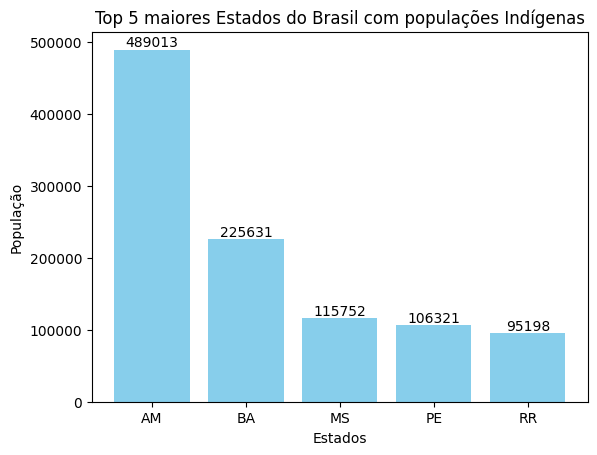

In [16]:
# Gráfico de barras vertical
grafico_barra_vertical = plt.bar(
    top_5_populacao_indigena_por_uf['sigla_uf'], # Eixo X
    top_5_populacao_indigena_por_uf['populacao_indigena_total'], # Eixo Y
    color='skyblue' # Cor das barras
)
plt.xlabel('Estados') # Título do Eixo X
plt.ylabel('População') # Título do Eixo Y
plt.title('Top 5 maiores Estados do Brasil com populações Indígenas') # Título do Gráfico

plt.bar_label(grafico_barra_vertical, label_type='edge') # Rótulos: Adiciona os números acima das barras
plt.show()

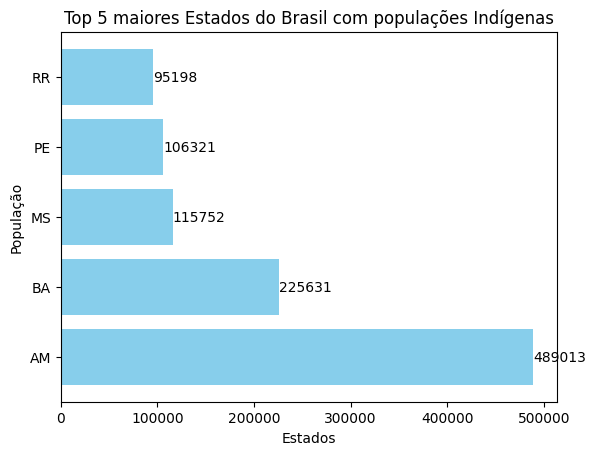

In [17]:
# Gráfico de barras horizontal
grafico_barra_horizontal = plt.barh(
    top_5_populacao_indigena_por_uf['sigla_uf'], # Eixo X
    top_5_populacao_indigena_por_uf['populacao_indigena_total'], # Eixo Y
    color='skyblue' # Cor das barras
)
plt.xlabel('Estados') # Título do Eixo X
plt.ylabel('População') # Título do Eixo Y
plt.title('Top 5 maiores Estados do Brasil com populações Indígenas') # Título do Gráfico

plt.bar_label(grafico_barra_horizontal, label_type='edge') # Rótulos: Adiciona os números acima das barras
plt.show()

### Exportação

In [18]:
# Salva o dataframe em um arquivo CSV 
top_5_populacao_indigena_por_uf.to_csv(r'..\saida\top_5_populacao_indigena_por_uf.csv')